# Faster R-CNN — Huấn luyện phát hiện mũ bảo hiểm
**Môi trường:** Jupyter local | **Dataset:** dataset_coco_cropped | **Backbone:** ResNet-50 FPN V2 (COCO pre-trained)

> Notebook này dùng `fasterrcnn_resnet50_fpn_v2` với weights pre-trained toàn bộ trên COCO (backbone + RPN + ROI Head). Fine-tune lại trên dataset helmet với LR thấp.

In [1]:
!unzip "dataset_coco_cropped.zip" -d "/workspace/"

Archive:  dataset_coco_cropped.zip
   creating: /workspace/dataset_coco_cropped/
   creating: /workspace/dataset_coco_cropped/test/
   creating: /workspace/dataset_coco_cropped/test/images/
  inflating: /workspace/dataset_coco_cropped/test/images/ds1_001_6_jpg.rf.HvNY7Mbteh9uKJYAyN3r.jpg  
  inflating: /workspace/dataset_coco_cropped/test/images/ds1_002_7_jpg.rf.b20K2r14MUxVbBjNXO0n.jpg  
  inflating: /workspace/dataset_coco_cropped/test/images/ds1_02c8f86a36d2d82f1988dbc38a91c91b_jpg.rf.B4addVDoSjZhnIE5k8ep.jpg  
  inflating: /workspace/dataset_coco_cropped/test/images/ds1_1-Rafale-SR20ONI20Dark20Grey_png_jpg.rf.3F1rqp9M99TKCQQyESHD.jpg  
  inflating: /workspace/dataset_coco_cropped/test/images/ds1_105_1cae94c5_d81a_4c7c_a2c2_10d0d4aed297_jpeg_jpg.rf.9dUtHnFE7hpBZujDfIAt.jpg  
  inflating: /workspace/dataset_coco_cropped/test/images/ds1_105_1cae94c5_d81a_4c7c_a2c2_10d0d4aed297_jpeg_jpg.rf.Pelrz2vXy1sTIQVo3ZWE.jpg  
  inflating: /workspace/dataset_coco_cropped/test/images/ds1_105_jpg.r

## 1. Kiểm tra thư viện

In [9]:
# Bỏ comment nếu chưa cài:
# !pip install torch torchvision pycocotools albumentations opencv-python

import importlib
required = {"torch":"torch","torchvision":"torchvision","pycocotools":"pycocotools",
            "albumentations":"albumentations","cv2":"opencv-python"}
for mod, pkg in required.items():
    try:
        importlib.import_module(mod)
        print(f"  OK      {mod}")
    except ImportError:
        print(f"  MISSING {mod}  ->  pip install {pkg}")

  OK      torch
  OK      torchvision
  OK      pycocotools
  OK      albumentations
  OK      cv2


## 2. Import

In [10]:
import os, time, csv, random
import numpy as np
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import cv2


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device  :", device)
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.version.cuda if torch.cuda.is_available() else "N/A")
if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
    vram = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)
    print("VRAM    :", vram, "GB")

Device  : cuda
PyTorch : 2.11.0+cu126
CUDA    : 12.6
GPU     : NVIDIA GeForce RTX 4090
VRAM    : 23.6 GB


In [8]:
%pip install cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 45.7 MB/s  0:00:00eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install pycocotools

Note: you may need to restart the kernel to use updated packages.


## 3. Cấu hình đường dẫn và hyperparameter

In [11]:
# ===== PATHS =====
BASE_DIR    = os.getcwd()
DATASET_DIR = os.path.normpath(os.path.join(BASE_DIR, "..", "workspace", "dataset_coco_cropped"))

TRAIN_IMG = os.path.join(DATASET_DIR, "train", "images")
TRAIN_ANN = os.path.join(DATASET_DIR, "train", "_annotations.coco.json")
VALID_IMG = os.path.join(DATASET_DIR, "valid", "images")
VALID_ANN = os.path.join(DATASET_DIR, "valid", "_annotations.coco.json")
TEST_IMG  = os.path.join(DATASET_DIR, "test",  "images")
TEST_ANN  = os.path.join(DATASET_DIR, "test",  "_annotations.coco.json")
OUTPUT_DIR = os.path.join(BASE_DIR, "faster_rcnn_v2_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ===== CHECKPOINT (fine-tune tu model tot nhat) =====
# Dat duong dan toi file .pth muon load, hoac None de fine-tune tu COCO weights
CHECKPOINT_PATH = None  # Fine-tune tu COCO pre-trained, khong can load checkpoint

# ===== HYPERPARAMETERS =====
NUM_EPOCHS                = 30
BATCH_SIZE                = 4
# LR thap vi fine-tune tu COCO pre-trained (da co weights tot)
LR_HEAD                   = 0.000561
LR_BACKBONE               = 0.0008
MOMENTUM                  = 0.9
WEIGHT_DECAY              = 0.00291
DROPOUT_RATE              = 0.1
GRAD_CLIP_NORM            = 5.0
EARLY_STOPPING_PATIENCE   = 10   # tang tu 6 -> 10 tranh dung som
MIN_DELTA                 = 1e-4
TRAINABLE_BACKBONE_LAYERS = 3  # Fine-tune 3 layer cuoi backbone
NUM_WORKERS = 0 if os.name == "nt" else 2

# Kiem tra duong dan
print("===== PATHS =====")
for name, p in [("DATASET_DIR", DATASET_DIR), ("TRAIN_IMG", TRAIN_IMG),
                ("TRAIN_ANN", TRAIN_ANN), ("VALID_IMG", VALID_IMG),
                ("VALID_ANN", VALID_ANN), ("OUTPUT_DIR", OUTPUT_DIR)]:
    status = "OK" if os.path.exists(p) else "KHONG TIM THAY"
    print(f"  {status:15}  {name}")

ckpt_status = "OK" if CHECKPOINT_PATH and os.path.exists(CHECKPOINT_PATH) else "KHONG TIM THAY"
print(f"  {ckpt_status:15}  CHECKPOINT_PATH: {CHECKPOINT_PATH}")

print(f"===== HYPERPARAMETERS (ResNet-50 FPN V2, fine-tune COCO) =====")
print(f"  Epochs:          {NUM_EPOCHS}")
print(f"  Batch size:      {BATCH_SIZE}")
print(f"  LR head:         {LR_HEAD}  |  backbone: {LR_BACKBONE}  (fine-tune)")
print(f"  Weight decay:    {WEIGHT_DECAY}  |  Dropout: {DROPOUT_RATE}")
print(f"  Backbone layers: {TRAINABLE_BACKBONE_LAYERS}")
print(f"  Patience:        {EARLY_STOPPING_PATIENCE}")
print(f"  Scheduler:       CosineAnnealingLR")
print(f"  Num workers:     {NUM_WORKERS}")
print(f"  Output dir:      {OUTPUT_DIR}")

===== PATHS =====
  OK               DATASET_DIR
  OK               TRAIN_IMG
  OK               TRAIN_ANN
  OK               VALID_IMG
  OK               VALID_ANN
  OK               OUTPUT_DIR
  KHONG TIM THAY   CHECKPOINT_PATH: None
===== HYPERPARAMETERS (ResNet-50 FPN V2, fine-tune COCO) =====
  Epochs:          30
  Batch size:      4
  LR head:         0.000561  |  backbone: 0.0008  (fine-tune)
  Weight decay:    0.00291  |  Dropout: 0.1
  Backbone layers: 3
  Patience:        10
  Scheduler:       CosineAnnealingLR
  Num workers:     2
  Output dir:      /workspace/faster_rcnn_v2_output


## 4. Dataset

In [12]:
class HelmetDataset(Dataset):
    def __init__(self, img_dir, ann_file, is_train=True):
        self.img_dir  = img_dir
        self.coco     = COCO(ann_file)
        self.ids      = list(self.coco.imgs.keys())
        self.is_train = is_train

        if self.is_train:
            self.transforms = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.40),
                A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.30),
                A.OneOf([
                    A.MotionBlur(blur_limit=3, p=1.0),
                    A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                    A.ImageCompression(quality_lower=65, quality_upper=95, p=1.0),
                ], p=0.30),
                A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=15, border_mode=0, p=0.40),
                A.Perspective(scale=(0.02, 0.08), p=0.25),
                A.CoarseDropout(max_holes=8, max_height=32, max_width=32, min_holes=1, fill_value=0, p=0.30),
                A.OneOf([
                    A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.30, p=1.0),
                    A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=15, drop_width=1,
                                 drop_color=(200,200,200), blur_value=3, brightness_coefficient=0.9, p=1.0),
                ], p=0.20),
                ToTensorV2(),
            ], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["labels"],
                                        clip=True, min_visibility=0.30))
        else:
            self.transforms = A.Compose([
                ToTensorV2(),
            ], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["labels"], clip=True))

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id   = self.ids[idx]
        img_info = self.coco.imgs[img_id]
        img_path = os.path.join(self.img_dir, img_info["file_name"])
        img      = np.array(Image.open(img_path).convert("RGB"))

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns    = self.coco.loadAnns(ann_ids)

        boxes, labels, areas, iscrowd = [], [], [], []
        for ann in anns:
            x, y, w, h = [float(v) for v in ann["bbox"]]
            if w <= 1 or h <= 1:
                continue
            boxes.append([x, y, x + w, y + h])
            labels.append(int(ann["category_id"]))
            areas.append(float(ann.get("area", w * h)))
            iscrowd.append(int(ann.get("iscrowd", 0)))

        transformed = self.transforms(image=img, bboxes=boxes, labels=labels)
        img_tensor  = transformed["image"].float() / 255.0

        if len(transformed["bboxes"]) > 0:
            boxes   = torch.tensor(transformed["bboxes"], dtype=torch.float32)
            labels  = torch.tensor(transformed["labels"],  dtype=torch.int64)
            areas   = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
            iscrowd = torch.zeros((len(labels),), dtype=torch.int64)
        else:
            boxes   = torch.zeros((0, 4), dtype=torch.float32)
            labels  = torch.zeros((0,),   dtype=torch.int64)
            areas   = torch.zeros((0,),   dtype=torch.float32)
            iscrowd = torch.zeros((0,),   dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels,
                  "image_id": torch.tensor([img_id]), "area": areas, "iscrowd": iscrowd}
        return img_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


# Test nhanh
_ds = HelmetDataset(TRAIN_IMG, TRAIN_ANN, is_train=False)
_img, _tgt = _ds[0]
print(f"Train : {len(HelmetDataset(TRAIN_IMG, TRAIN_ANN))} anh")
print(f"Valid : {len(HelmetDataset(VALID_IMG, VALID_ANN))} anh")
print(f"Test  : {len(HelmetDataset(TEST_IMG, TEST_ANN))} anh")
print(f"Image : {_img.shape}  |  Boxes: {_tgt['boxes'].shape}  |  Labels: {_tgt['labels']}")
print("Dataset OK!")

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...


/venv/main/lib/python3.12/site-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


index created!
Train : 3932 anh
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Valid : 491 anh
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Test  : 492 anh
Image : torch.Size([3, 142, 186])  |  Boxes: torch.Size([1, 4])  |  Labels: tensor([2])
Dataset OK!


/tmp/ipykernel_1393/1686080595.py:16: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=65, quality_upper=95, p=1.0),
/venv/main/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1393/1686080595.py:20: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, min_holes=1, fill_value=0, p=0.30),
/tmp/ipykernel_1393/1686080595.py:22: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.30, p=1.0),
/tmp/ipykernel_1393/1686080595.py:23: UserWarning: Argument(s) 'slant_lower, slant_upper' are not valid for trans

## 5. Model — Faster R-CNN ResNet-50 FPN V2 (COCO pre-trained)

In [13]:
class TwoMLPHeadDropout(nn.Module):
    """ROI Head với Dropout để giảm overfitting."""
    def __init__(self, in_channels, representation_size, dropout=0.2):
        super().__init__()
        self.fc6  = nn.Linear(in_channels, representation_size)
        self.fc7  = nn.Linear(representation_size, representation_size)
        self.drop = nn.Dropout(p=dropout)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = self.drop(F.relu(self.fc6(x)))
        x = self.drop(F.relu(self.fc7(x)))
        return x


def build_faster_rcnn(num_classes, trainable_backbone_layers=3, dropout=0.2):
    """
    Faster R-CNN ResNet-50 FPN V2 — full COCO pre-trained.
    V2 dung FastRCNNConvFCHead (Conv + FC) thay vi TwoMLPHead.
    -> Them Dropout vao cac FC layer hien co, thay predictor.
    """
    # Load toan bo model da pre-train tren COCO (backbone + RPN + ROI Head)
    model = fasterrcnn_resnet50_fpn_v2(
        weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT,
        trainable_backbone_layers=trainable_backbone_layers,
        min_size=640, max_size=1024,
    )
    # V2 dung FastRCNNConvFCHead: chen Dropout vao sau moi FC layer
    # Giu nguyen Conv layers (da pre-train), chi them Dropout vao phan FC
    if dropout > 0:
        new_layers = []
        for layer in model.roi_heads.box_head.children():
            new_layers.append(layer)
            if isinstance(layer, nn.Linear):
                new_layers.append(nn.Dropout(p=dropout))
        model.roi_heads.box_head = nn.Sequential(*new_layers)
    # Thay predictor: COCO co 91 class, dataset helmet chi co 3 class
    in_features                   = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


model = build_faster_rcnn(
    num_classes=3,
    trainable_backbone_layers=TRAINABLE_BACKBONE_LAYERS,
    dropout=DROPOUT_RATE,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model         : Faster R-CNN ResNet-50 FPN V2 (COCO pre-trained)")
print(f"Tong tham so  : {total_params:,}")
print(f"Trainable     : {train_params:,}")
print(f"Dropout ROI   : {DROPOUT_RATE}")
print(f"Backbone layer: {TRAINABLE_BACKBONE_LAYERS}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:02<00:00, 72.4MB/s] 


Model         : Faster R-CNN ResNet-50 FPN V2 (COCO pre-trained)
Tong tham so  : 43,261,278
Trainable     : 43,035,934
Dropout ROI   : 0.1
Backbone layer: 3


## 6. Hàm đánh giá (Val Loss + Precision/Recall/F1)

In [14]:
def compute_val_loss(model, val_loader, device):
    """Tính val loss không update trọng số."""
    model.train()
    total = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            total += sum(l for l in loss_dict.values()).item()
    return total / max(len(val_loader), 1)


def _box_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0.0, xB - xA) * max(0.0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0


def evaluate_prf(model, val_loader, device, iou_thresh=0.5, score_thresh=0.5):
    """Tính Precision, Recall, F1 và Mean IoU trên tập validation."""
    model.eval()
    tp = fp = fn = 0
    iou_sum = 0.0   # tong IoU cua cac cap TP (pred, gt)
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs    = [img.to(device) for img in imgs]
            outputs = model(imgs)
            for target, out in zip(targets, outputs):
                gt_boxes    = target["boxes"].cpu().numpy()
                pred_boxes  = out["boxes"].cpu().numpy()
                pred_scores = out["scores"].cpu().numpy()
                keep        = pred_scores >= score_thresh
                pred_boxes  = pred_boxes[keep]
                pred_scores = pred_scores[keep]
                order       = pred_scores.argsort()[::-1]
                pred_boxes  = pred_boxes[order]
                gt_matched  = [False] * len(gt_boxes)
                tp_img = 0
                for pb in pred_boxes:
                    best_iou, best_gi = iou_thresh - 1e-9, -1
                    for gi, gb in enumerate(gt_boxes):
                        if gt_matched[gi]: continue
                        iou = _box_iou(pb, gb)
                        if iou > best_iou:
                            best_iou, best_gi = iou, gi
                    if best_gi >= 0:
                        gt_matched[best_gi] = True
                        tp_img += 1
                        iou_sum += best_iou   # cong don IoU cua cap TP nay
                fp += len(pred_boxes) - tp_img
                fn += sum(1 for m in gt_matched if not m)
                tp += tp_img
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0
    mean_iou  = iou_sum / tp if tp > 0 else 0.0   # trung binh IoU tren cac TP
    return precision, recall, f1, mean_iou


print("Functions san sang!")

Functions san sang!


## 7. DataLoader + Optimizer

In [15]:
train_loader = DataLoader(
    HelmetDataset(TRAIN_IMG, TRAIN_ANN, is_train=True),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    HelmetDataset(VALID_IMG, VALID_ANN, is_train=False),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

print(f"Train: {len(train_loader.dataset)} anh | {len(train_loader)} batches")
print(f"Valid: {len(val_loader.dataset)} anh | {len(val_loader)} batches")

# Khoi tao model
model = build_faster_rcnn(
    num_classes=3,
    trainable_backbone_layers=TRAINABLE_BACKBONE_LAYERS,
    dropout=DROPOUT_RATE,
).to(device)

# Load checkpoint neu co
if CHECKPOINT_PATH and os.path.exists(CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    print(f"Da load checkpoint: {CHECKPOINT_PATH}")
else:
    print("Khong co checkpoint -> fine-tune tu COCO pre-trained weights")

backbone_params, head_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad: continue
    (backbone_params if name.startswith("backbone") else head_params).append(param)

optimizer = torch.optim.SGD(
    [{"params": backbone_params, "lr": LR_BACKBONE},
     {"params": head_params,     "lr": LR_HEAD}],
    momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True,
)

# CosineAnnealingLR: giam LR muot theo duong cong cosine
# Tranh plateau cung nhu dao dong nhu ReduceLROnPlateau
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,  # giam tu LR_HEAD ve eta_min trong NUM_EPOCHS epoch
    eta_min=1e-4,
)

print(f"Backbone params: {sum(p.numel() for p in backbone_params):,}")
print(f"Head params    : {sum(p.numel() for p in head_params):,}")
print(f"LR head / backbone : {LR_HEAD} / {LR_BACKBONE}")
print(f"Scheduler          : CosineAnnealingLR(T_max={NUM_EPOCHS}, eta_min=1e-7)")

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Train: 3932 anh | 983 batches
Valid: 491 anh | 123 batches


/tmp/ipykernel_1393/1686080595.py:16: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=65, quality_upper=95, p=1.0),
/tmp/ipykernel_1393/1686080595.py:20: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, min_holes=1, fill_value=0, p=0.30),
/tmp/ipykernel_1393/1686080595.py:22: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.30, p=1.0),
/tmp/ipykernel_1393/1686080595.py:23: UserWarning: Argument(s) 'slant_lower, slant_upper' are not valid for transform RandomRain
  A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=15, drop_width=1,


Khong co checkpoint -> fine-tune tu COCO pre-trained weights
Backbone params: 26,629,120
Head params    : 16,406,814
LR head / backbone : 0.000561 / 0.0008
Scheduler          : CosineAnnealingLR(T_max=30, eta_min=1e-7)


## 8. Huấn luyện

In [16]:
best_val_loss     = float("inf")
best_precision    = 0.0
best_recall       = 0.0
best_f1           = 0.0
best_iou          = 0.0
best_epoch        = 0
epochs_no_improve = 0

history = {"epoch": [], "train_loss": [], "val_loss": [],
           "precision": [], "recall": [], "f1": [], "iou": []}

print(f"\nBat dau train Faster R-CNN — {NUM_EPOCHS} epochs")
print("=" * 102)
print(f"  {'Epoch':>5} {'Train':>10} {'Val':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'IoU':>8} {'LR':>9} {'Time':>6}")
print("=" * 102)

total_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start      = time.time()
    model.train()
    total_train_loss = 0.0
    is_best          = False

    for i, (images, targets) in enumerate(train_loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses    = sum(l for l in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        total_train_loss += losses.item()

        if (i + 1) % 100 == 0:
            print(f"  Ep {epoch:02d} | Iter {i+1}/{len(train_loader)} | Loss: {losses.item():.4f}", flush=True)

    train_loss             = total_train_loss / max(len(train_loader), 1)
    val_loss               = compute_val_loss(model, val_loader, device)
    precision, recall, f1, mean_iou = evaluate_prf(model, val_loader, device)
    elapsed                = (time.time() - epoch_start) / 60

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["precision"].append(precision)
    history["recall"].append(recall)
    history["f1"].append(f1)
    history["iou"].append(mean_iou)

    # CosineAnnealingLR: step() khong can val_loss
    lr_scheduler.step()

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss

    if f1 > best_f1 + MIN_DELTA:
        is_best = True
        best_precision, best_recall, best_f1, best_iou, best_epoch = precision, recall, f1, mean_iou, epoch
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "faster_rcnn_best.pth"))
        print(f"  => [BEST] P={precision:.4f} | R={recall:.4f} | F1={f1:.4f}", flush=True)
    else:
        epochs_no_improve += 1
        print(f"  => No improve {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} (F1={f1:.4f})", flush=True)

    # Lưu checkpoint
    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, f"faster_rcnn_epoch_{epoch:02d}.pth"))

    # Lưu CSV
    with open(os.path.join(OUTPUT_DIR, "training_history.csv"), "w", newline="") as f_csv:
        writer = csv.DictWriter(f_csv, fieldnames=["epoch","train_loss","val_loss","precision","recall","f1","iou"])
        writer.writeheader()
        for k in range(len(history["epoch"])):
            writer.writerow({"epoch": history["epoch"][k], "train_loss": history["train_loss"][k],
                             "val_loss": history["val_loss"][k], "precision": history["precision"][k],
                             "recall": history["recall"][k], "f1": history["f1"][k],
                             "iou": history["iou"][k]})

    print("-" * 102)
    print(f"  {epoch:>5} {train_loss:>10.4f} {val_loss:>10.4f} {precision:>10.4f} {recall:>8.4f} "
          f"{f1:>8.4f} {mean_iou:>8.4f} {optimizer.param_groups[1]['lr']:>9.6f} {elapsed:>5.1f}m  {'Best' if is_best else ''}")
    print("-" * 102)

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\nEARLY STOP tai epoch {epoch}")
        break

total_time = (time.time() - total_start) / 60
print("=" * 102)
print(f"\nHoan thanh! Tong thoi gian: {total_time:.1f} phut")
print(f"  Best epoch    : {best_epoch}")
print(f"  Best Val Loss : {best_val_loss:.4f}")
print(f"  Best Precision: {best_precision:.4f}")
print(f"  Best Recall   : {best_recall:.4f}")
print(f"  Best F1       : {best_f1:.4f}")
print(f"  Best IoU      : {best_iou:.4f}")
print(f"  Model luu tai : {os.path.join(OUTPUT_DIR, 'faster_rcnn_best.pth')}")


Bat dau train Faster R-CNN — 30 epochs
  Epoch      Train        Val  Precision   Recall       F1      IoU        LR   Time
  Ep 01 | Iter 100/983 | Loss: 0.6890
  Ep 01 | Iter 200/983 | Loss: 0.4277
  Ep 01 | Iter 300/983 | Loss: 0.1689
  Ep 01 | Iter 400/983 | Loss: 0.1338
  Ep 01 | Iter 500/983 | Loss: 0.1891
  Ep 01 | Iter 600/983 | Loss: 0.2618
  Ep 01 | Iter 700/983 | Loss: 0.3177
  Ep 01 | Iter 800/983 | Loss: 0.2630
  Ep 01 | Iter 900/983 | Loss: 0.2379
  => [BEST] P=0.7032 | R=0.8153 | F1=0.7551
------------------------------------------------------------------------------------------------------
      1     0.2806     0.2016     0.7032   0.8153   0.7551   0.7752  0.000560   3.9m  Best
------------------------------------------------------------------------------------------------------
  Ep 02 | Iter 100/983 | Loss: 0.2093
  Ep 02 | Iter 200/983 | Loss: 0.0775
  Ep 02 | Iter 300/983 | Loss: 0.2947
  Ep 02 | Iter 400/983 | Loss: 0.1457
  Ep 02 | Iter 500/983 | Loss: 0.2145
  

## 9. Biểu đồ kết quả

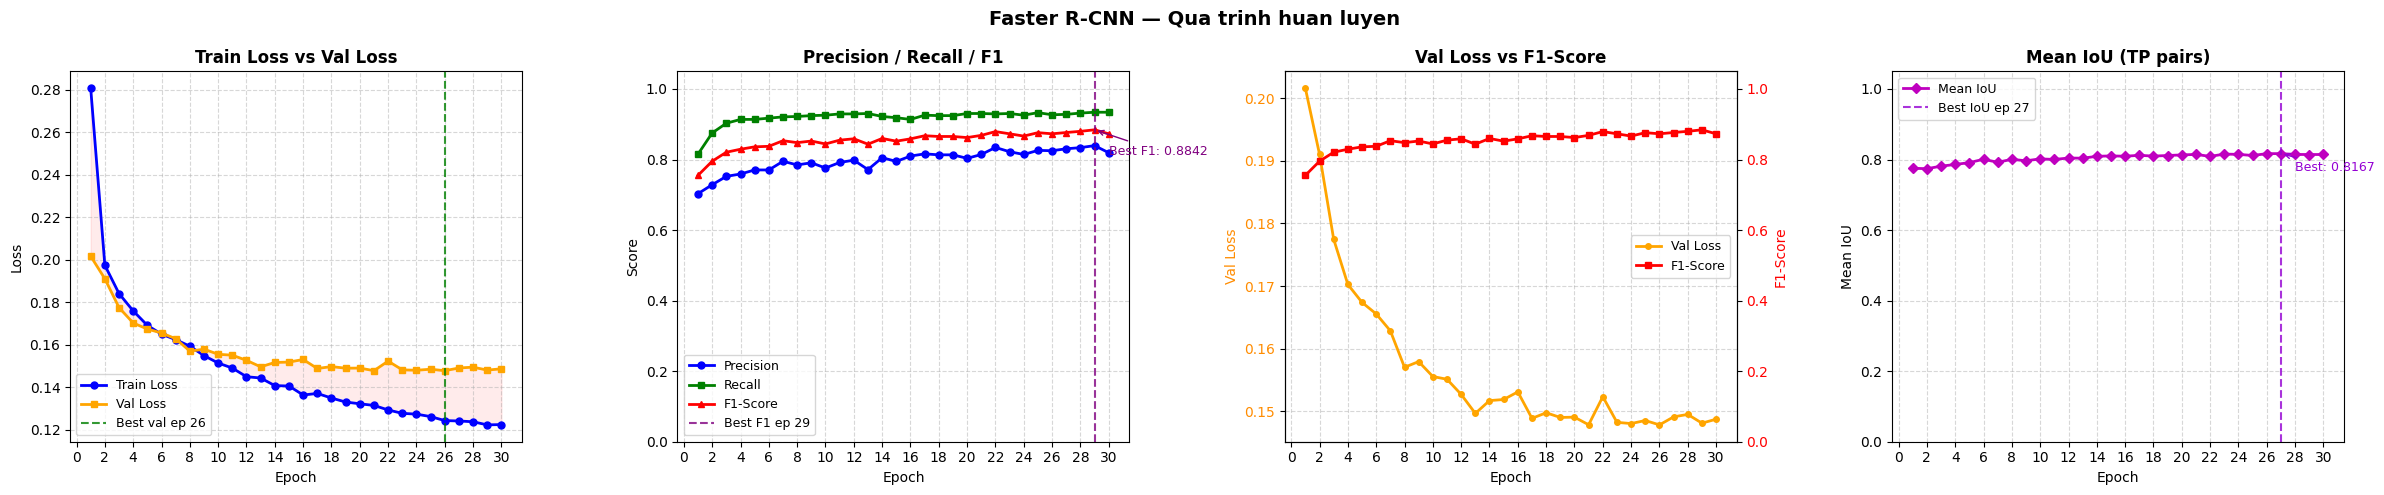

Da luu bieu do: /workspace/faster_rcnn_v2_output/training_curve.png

 Epoch    Train    Valid  Precision   Recall       F1      IoU
     1   0.2806   0.2016     0.7032   0.8153   0.7551   0.7752
     2   0.1974   0.1910     0.7285   0.8753   0.7952   0.7740
     3   0.1841   0.1775     0.7522   0.9029   0.8207   0.7812
     4   0.1759   0.1702     0.7590   0.9137   0.8292   0.7860
     5   0.1691   0.1674     0.7705   0.9137   0.8360   0.7912
     6   0.1650   0.1655     0.7704   0.9173   0.8374   0.8008
     7   0.1624   0.1628     0.7950   0.9209   0.8533   0.7921
     8   0.1593   0.1570     0.7847   0.9221   0.8479   0.8006
     9   0.1549   0.1579     0.7908   0.9245   0.8524   0.7964
    10   0.1514   0.1555     0.7759   0.9257   0.8442   0.8019
    11   0.1490   0.1551     0.7916   0.9293   0.8549   0.8002
    12   0.1450   0.1527     0.7981   0.9293   0.8587   0.8043
    13   0.1444   0.1496     0.7714   0.9305   0.8435   0.8038
    14   0.1408   0.1517     0.8052   0.9221   0.

In [17]:
csv_path = os.path.join(OUTPUT_DIR, "training_history.csv")
df = pd.read_csv(csv_path)

best_val_epoch = df.loc[df["val_loss"].idxmin(), "epoch"]
best_f1_epoch  = df.loc[df["f1"].idxmax(),       "epoch"]
best_f1_val    = df["f1"].max()

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Faster R-CNN — Qua trinh huan luyen", fontsize=14, fontweight="bold")

# Train Loss vs Val Loss
ax1 = axes[0]
ax1.plot(df["epoch"], df["train_loss"], "b-o", lw=2, ms=5, label="Train Loss")
ax1.plot(df["epoch"], df["val_loss"], "orange", marker="s", lw=2, ms=5, label="Val Loss")
ax1.fill_between(df["epoch"], df["train_loss"], df["val_loss"], alpha=0.08, color="red")
ax1.axvline(x=best_val_epoch, color="green", ls="--", alpha=0.8, label=f"Best val ep {int(best_val_epoch)}")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Train Loss vs Val Loss", fontweight="bold")
ax1.grid(True, ls="--", alpha=0.5); ax1.legend(fontsize=9)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(2))

# Precision / Recall / F1
ax2 = axes[1]
ax2.plot(df["epoch"], df["precision"], "b-o", lw=2, ms=5, label="Precision")
ax2.plot(df["epoch"], df["recall"],    "g-s", lw=2, ms=5, label="Recall")
ax2.plot(df["epoch"], df["f1"],        "r-^", lw=2, ms=5, label="F1-Score")
ax2.axvline(x=best_f1_epoch, color="purple", ls="--", alpha=0.8, label=f"Best F1 ep {int(best_f1_epoch)}")
ax2.annotate(f"Best F1: {best_f1_val:.4f}",
             xy=(best_f1_epoch, best_f1_val), xytext=(best_f1_epoch+1, best_f1_val-0.07),
             fontsize=9, color="purple", arrowprops=dict(arrowstyle="->", color="purple"))
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
ax2.set_title("Precision / Recall / F1", fontweight="bold")
ax2.set_ylim(0, 1.05); ax2.grid(True, ls="--", alpha=0.5); ax2.legend(fontsize=9)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(2))

# Val Loss vs F1 (dual axis)
ax3 = axes[2]
l1, = ax3.plot(df["epoch"], df["val_loss"], "orange", marker="o", lw=2, ms=4, label="Val Loss")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Val Loss", color="darkorange")
ax3.tick_params(axis="y", labelcolor="darkorange")
ax3b = ax3.twinx()
l2, = ax3b.plot(df["epoch"], df["f1"], "r-s", lw=2, ms=4, label="F1-Score")
ax3b.set_ylabel("F1-Score", color="red"); ax3b.tick_params(axis="y", labelcolor="red")
ax3b.set_ylim(0, 1.05)
ax3.set_title("Val Loss vs F1-Score", fontweight="bold")
ax3.grid(True, ls="--", alpha=0.5)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax3.legend(handles=[l1, l2], loc="center right", fontsize=9)

# Mean IoU theo epoch
best_iou_epoch = df.loc[df["iou"].idxmax(), "epoch"]
best_iou_val   = df["iou"].max()
ax4 = axes[3]
ax4.plot(df["epoch"], df["iou"], "m-D", lw=2, ms=5, label="Mean IoU")
ax4.axvline(x=best_iou_epoch, color="darkviolet", ls="--", alpha=0.8,
            label=f"Best IoU ep {int(best_iou_epoch)}")
ax4.annotate(f"Best: {best_iou_val:.4f}",
             xy=(best_iou_epoch, best_iou_val),
             xytext=(best_iou_epoch + 1, best_iou_val - 0.05),
             fontsize=9, color="darkviolet",
             arrowprops=dict(arrowstyle="->", color="darkviolet"))
ax4.set_xlabel("Epoch"); ax4.set_ylabel("Mean IoU")
ax4.set_title("Mean IoU (TP pairs)", fontweight="bold")
ax4.set_ylim(0, 1.05); ax4.grid(True, ls="--", alpha=0.5); ax4.legend(fontsize=9)
ax4.xaxis.set_major_locator(ticker.MultipleLocator(2))

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "training_curve.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Da luu bieu do: {save_path}")

# Bảng tổng kết
print(f"\n{'='*76}")
print(f"{'Epoch':>6} {'Train':>8} {'Valid':>8} {'Precision':>10} {'Recall':>8} {'F1':>8} {'IoU':>8}")
print(f"{'='*86}")
for _, row in df.iterrows():
    marker = " <- Best F1" if row["epoch"] == best_f1_epoch else ""
    print(f"{int(row['epoch']):>6} {row['train_loss']:>8.4f} {row['val_loss']:>8.4f} "
          f"{row['precision']:>10.4f} {row['recall']:>8.4f} {row['f1']:>8.4f} {row['iou']:>8.4f}{marker}")
print(f"{'='*86}")

## 10. Inference — Kiểm tra trên ảnh

In [ ]:
# ---- Đổi đường dẫn ở đây ----
IMAGE_PATH     = r"duong_dan_anh_cua_ban.jpg"
CONF_THRESHOLD = 0.60
MODEL_PATH     = os.path.join(OUTPUT_DIR, "faster_rcnn_best.pth")

CLASS_INFO = {
    1: {"name": "Helmet",    "color": (0, 200, 0)},
    2: {"name": "No_Helmet", "color": (220, 0, 0)},
}


def load_infer_model(model_path, num_classes=3):
    m = build_faster_rcnn(num_classes=num_classes, trainable_backbone_layers=0)
    m.load_state_dict(torch.load(model_path, map_location=device))
    m.to(device); m.eval()
    return m


if not os.path.exists(IMAGE_PATH):
    print(f"Khong tim thay anh: {IMAGE_PATH}")
    print("Hay doi IMAGE_PATH sang duong dan thuc su.")
else:
    infer_model = load_infer_model(MODEL_PATH)
    img_bgr     = cv2.imread(IMAGE_PATH)
    img_rgb     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor      = torch.from_numpy(img_rgb / 255.0).permute(2, 0, 1).float().to(device)

    with torch.no_grad():
        pred = infer_model([tensor])[0]

    img_draw = img_rgb.copy()
    count = {"Helmet": 0, "No_Helmet": 0}
    for box, label, score in zip(pred["boxes"], pred["labels"], pred["scores"]):
        if score < CONF_THRESHOLD: continue
        lid  = int(label)
        if lid not in CLASS_INFO: continue
        x1, y1, x2, y2 = box.int().cpu().numpy()
        info = CLASS_INFO[lid]
        count[info["name"]] += 1
        cv2.rectangle(img_draw, (x1, y1), (x2, y2), info["color"], 2)
        text = f"{info['name']} {score*100:.0f}%"
        cv2.putText(img_draw, text, (x1, max(y1-7, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,0,0), 3)
        cv2.putText(img_draw, text, (x1, max(y1-7, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, info["color"], 1)

    plt.figure(figsize=(14, 8))
    plt.imshow(img_draw)
    plt.axis("off")
    plt.title(f"Helmet={count['Helmet']}  |  No_Helmet={count['No_Helmet']}", fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f"Phat hien: Helmet={count['Helmet']}, No_Helmet={count['No_Helmet']}")

## 11. Inference — Xử lý video

In [ ]:
# ---- Đổi đường dẫn ở đây ----
VIDEO_INPUT    = r"duong_dan_video_input.mp4"
VIDEO_OUTPUT   = os.path.join(OUTPUT_DIR, "result_video.mp4")
CONF_THRESHOLD = 0.60
MODEL_PATH     = os.path.join(OUTPUT_DIR, "faster_rcnn_best.pth")

CLASS_INFO = {
    1: {"name": "Helmet",    "color": (0, 200, 0)},
    2: {"name": "No_Helmet", "color": (0, 0, 220)},
}

if not os.path.exists(VIDEO_INPUT):
    print(f"Khong tim thay video: {VIDEO_INPUT}")
    print("Hay doi VIDEO_INPUT sang duong dan thuc su.")
else:
    infer_model = load_infer_model(MODEL_PATH)

    cap    = cv2.VideoCapture(VIDEO_INPUT)
    W      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(VIDEO_OUTPUT, fourcc, fps, (W, H))

    print(f"Video : {W}x{H} | {fps} FPS | {total} frames")
    print(f"Output: {VIDEO_OUTPUT}")

    start = time.time(); count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        tensor = torch.from_numpy(rgb / 255.0).permute(2, 0, 1).float().to(device)
        with torch.no_grad():
            pred = infer_model([tensor])[0]
        for box, label, score in zip(pred["boxes"], pred["labels"], pred["scores"]):
            if score < CONF_THRESHOLD or int(label) not in CLASS_INFO: continue
            x1, y1, x2, y2 = box.int().cpu().numpy()
            info = CLASS_INFO[int(label)]
            cv2.rectangle(frame, (x1, y1), (x2, y2), info["color"], 2)
            cv2.putText(frame, f"{info['name']} {score:.2f}", (x1, max(y1-8, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, info["color"], 2)
        writer.write(frame)
        count += 1
        if count % 50 == 0:
            avg_fps = count / max(time.time()-start, 1e-6)
            print(f"  Frame {count}/{total} | {avg_fps:.1f} FPS", flush=True)

    cap.release(); writer.release()
    print(f"Xong! {(time.time()-start)/60:.2f} phut | Luu tai: {VIDEO_OUTPUT}")